In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# 2. Data Structure

In [3]:
print(train.shape,test.shape)


(577347, 12) (247435, 11)


In [4]:
print(train.isna().sum(),test.isna().sum())

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64 id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
dtype: int64


In [5]:
print(train.dtypes)

id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type         object
galaxy_population     object
class                 object
dtype: object


In [6]:
print(train.head())

   id       alpha      delta          u          g          r          i  \
0   0  147.734256  16.959273  25.472123  21.895559  20.357926  19.257113   
1   1  127.988677  32.346716  20.778509  19.087062  17.587208  17.226067   
2   2  179.792648  35.344843  21.035203  21.079128  21.171840  20.582629   
3   3  225.818295  48.569421  23.305056  21.050736  19.017754  18.365658   
4   4  141.836135  19.342852  21.703158  19.471680  18.234449  17.899447   

           z  redshift spectral_type galaxy_population   class  
0  18.621057  0.408982             M      Red_Sequence  GALAXY  
1  16.786433  0.157976             M      Red_Sequence  GALAXY  
2  20.557366  2.823770           O/B        Blue_Cloud     QSO  
3  17.914952  0.536099             M      Red_Sequence  GALAXY  
4  17.616185  0.555761             M      Red_Sequence  GALAXY  


In [7]:
print(train['class'].value_counts())
print(train['class'].value_counts(normalize=True))

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64
class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: proportion, dtype: float64


In [8]:
print(train["spectral_type"].value_counts())

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64


In [9]:
print(train["galaxy_population"].value_counts())

galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64


# 3. Explanatory Data Analyis (EDA)

In [10]:
for df in [train, test]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_z'] = df['u'] - df['z']

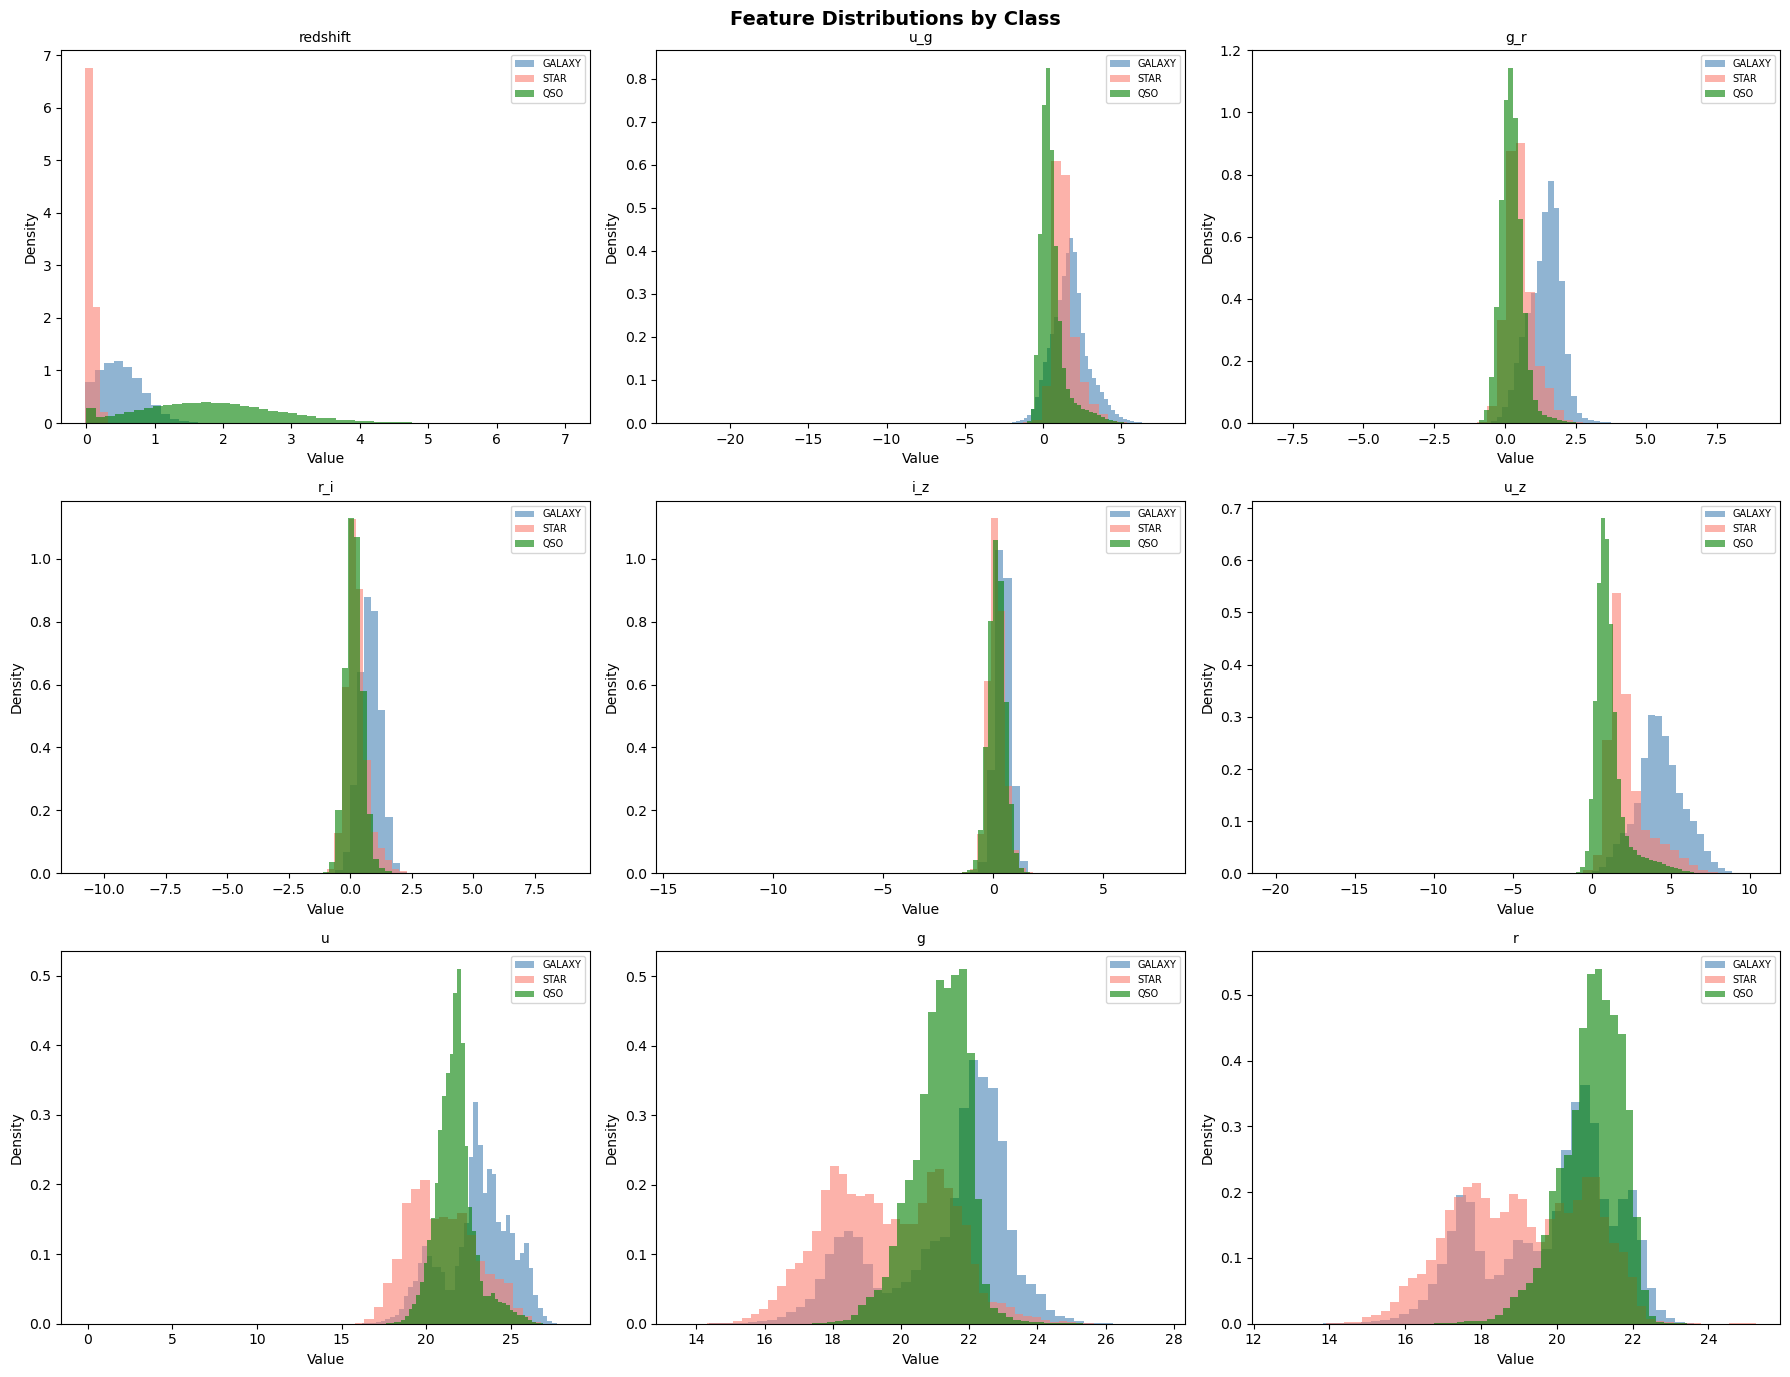

In [11]:
features_to_plot = ['redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z', 'u', 'g', 'r']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
fig.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')

for i , col in enumerate(features_to_plot):
    for cls,color in zip(['GALAXY', 'STAR', 'QSO'], ['steelblue', 'salmon', 'green']):
        axes[i].hist(train[train['class'] == cls][col], bins=50, 
                     alpha=0.6, label=cls, color=color, density=True)
    axes[i].set_title(col.strip(), fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

# 4. Preprocessing

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()

In [14]:
train["target"] = encoder.fit_transform(train["class"])
print(encoder.classes_)

['GALAXY' 'QSO' 'STAR']


In [15]:
for col in ['spectral_type', 'galaxy_population']:
    le_feat = LabelEncoder()
    train[col] = le_feat.fit_transform(train[col])
    test[col] = le_feat.transform(test[col])

In [16]:
print(train.dtypes)

id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type          int64
galaxy_population      int64
class                 object
u_g                  float64
g_r                  float64
r_i                  float64
i_z                  float64
u_z                  float64
target                 int64
dtype: object


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 
            'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z']

In [19]:
x = train[features]
y = train["target"]
x_test = test[features]

In [21]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
print(x_train.shape, x_val.shape)

(461877, 15) (115470, 15)


In [26]:
from lightgbm import LGBMClassifier
from sklearn.metrics import balanced_accuracy_score

In [28]:
model = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1)

model.fit(x_train, y_train)
y_pred = model.predict(x_val)
score = balanced_accuracy_score(y_val, y_pred)
print(f"Balanced Accuracy: {score:.4f}")

Balanced Accuracy: 0.9642


In [36]:
print(encoder.classes_)

['GALAXY' 'QSO' 'STAR']


In [37]:
y_test_pred = model.predict(x_test)
y_test_labels = encoder.inverse_transform(y_test_pred)

submission = pd.DataFrame({
    'id': test['id'],
    'class': y_test_labels
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print(submission['class'].value_counts())

       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
class
GALAXY    156296
QSO        51415
STAR       39724
Name: count, dtype: int64
